In [1]:
# ############################################################
# Level 3 — 쇼핑몰 고객 세분화 (공개 데이터 + 시각화)
# ############################################################
# ------------------------------------------------------------
# [목적] 도구 불러오기 — 표 / 배열 / 그래프 / 전처리 / 모델 / 평가
# ------------------------------------------------------------
import pandas as pd                               # 표(CSV) 다루기 (엑셀 같은 표 다루기)
import numpy as np                                # 개수 세기 (숫자 묶음 다루기)
import matplotlib.pyplot as plt                   # 그래프 (그림으로 그리기)
from sklearn.preprocessing import StandardScaler  # 스케일링 (숫자 크기 맞추기)
from sklearn.cluster import KMeans                # K-means (비슷한 고객끼리 묶기)
from sklearn.metrics import silhouette_score      # 실루엣 점수 (잘 나뉘었는지 성적)
%matplotlib inline

In [2]:
# ------------------------------------------------------------
# [목적] 데이터 불러오기 — 공개 URL(캐글 'Mall Customers'), 고객 200명
# ------------------------------------------------------------
url = 'https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv'
df = pd.read_csv(url)                             # 표로 읽기 (인터넷 주소에서 바로 불러오기, 다운로드 불필요)
df.head()                                          # 앞 5줄 (데이터 확인)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# ------------------------------------------------------------
# [목적] 전처리 — 두 특성 선택 + 스케일링
# ------------------------------------------------------------
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]  # 두 열 고르기 (연소득·소비점수만 사용)
X_s = StandardScaler().fit_transform(X)           # 스케일링 (소득 수백 vs 점수 100 단위 차이 맞추기)

In [4]:
# ------------------------------------------------------------
# [목적] 학습(5유형) + 평가 — 유형별 평균/인원/실루엣
# ------------------------------------------------------------
km = KMeans(n_clusters=5, random_state=0, n_init=10)   # 5유형 모델 (고객을 다섯 덩어리로)
df['segment'] = km.fit_predict(X_s)               # 유형 번호 부여 (각 고객이 0~4 중 어디인지)

print(df.groupby('segment')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))  # 유형별 평균 (덩어리별 대표값)
print('\n유형별 인원:', np.bincount(df['segment']))                     # 유형별 인원 (덩어리마다 몇 명인지)
print('실루엣 점수:', round(silhouette_score(X_s, df['segment']), 3))    # 품질 점수 (1에 가까울수록 깔끔)

         Annual Income (k$)  Spending Score (1-100)
segment                                            
0                      55.3                    49.5
1                      86.5                    82.1
2                      88.2                    17.1
3                      26.3                    20.9
4                      25.7                    79.4

유형별 인원: [81 39 35 23 22]
실루엣 점수: 0.555


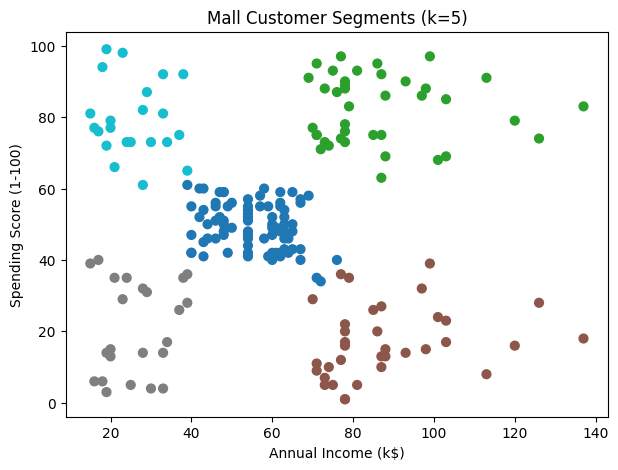

In [5]:
# ------------------------------------------------------------
# [목적] 시각화 — 소득(x) vs 소비점수(y), 색 = 유형
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))                        # 그림 크기 (가로7·세로5 도화지 준비)
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],  # 점 찍기 (고객 한 명이 점 하나)
            c=df['segment'], cmap='tab10', s=40)                   # 색=유형 (덩어리마다 다른 색)
plt.xlabel('Annual Income (k$)')                  # x축 이름 (가로축 = 소득)
plt.ylabel('Spending Score (1-100)')              # y축 이름 (세로축 = 소비점수)
plt.title('Mall Customer Segments (k=5)')         # 제목 (한글은 깨질 수 있어 영문으로)
plt.show()                                         # 그림 출력 (화면에 그래프 띄우기)

In [6]:
# ============================================================
# [결과 해석]  5개 유형이 소득·소비로 뚜렷이 갈림 (실루엣 0.555 -> 잘 나뉨)
#   seg | 연소득 | 소비 | 인원 | 이름(사람이 붙임)
#    1  |  86.5 | 82.1 |  39 | 고소득·고소비 = VIP
#    2  |  88.2 | 17.1 |  35 | 고소득·저소비 = 알뜰형
#    4  |  25.7 | 79.4 |  22 | 저소득·고소비 = 충동형
#    3  |  26.3 | 20.9 |  23 | 저소득·저소비 = 소극형
#    0  |  55.3 | 49.5 |  81 | 중간·중간     = 일반형
#   -> 산점도에서도 네 귀퉁이 + 가운데로 '다섯 덩어리'가 선명
#   -> 컴퓨터는 번호(0~4)만 주고, VIP·알뜰형 같은 이름은 사람이 붙임
# ============================================================